In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
from collections import defaultdict
from pathlib import Path
from tqdm.notebook import tqdm
import pickle
import random
from sklearn.preprocessing import StandardScaler


import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
def seed_everything(seed):
    torch.cuda.manual_seed(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    os.environ['PYHASHSEED'] = str(seed)

seed_everything(42)

## Data preprocessing

In [3]:
base_dir = Path('.')
train = pd.read_csv(base_dir / 'train.csv')
owner = pd.read_csv(base_dir / 'owner.csv')
sample_sub = pd.read_csv(base_dir / 'sample_submission.csv')
user = pd.read_csv(base_dir / 'user.csv', parse_dates=['create_date'])
video = pd.read_csv(base_dir / 'video.csv')

train.drop_duplicates(inplace=True)

print(f'Interactions: {len(train)}, Users: {train.user_id.nunique()}, Videos: {train.video_id.nunique()}')

Interactions: 5434520, Users: 152911, Videos: 228506


Frequency id encoding

маппинг делается **по частоте** (самый популярный = индекс 0). Это не влияет на качество напрямую, но позволяет при необходимости отсечь редкие категории по индексу.

In [4]:
owner['city_id'] = owner['city_id'].fillna('0')
un = owner['city_id'].value_counts().index
owner['city_id'] = owner['city_id'].map(dict(zip(un, range(len(un)))))

train['interaction_type'] = train['interaction_type'].map({'like': 2, 'view': 1})

user['gender'] = user['gender'].map({'F': 1, 'M': 0})
user['age'] = user['age'].fillna(user['age'].median())
user['language'] = user['language'].apply(lambda x: 1 if x == 'ru' else 0)
user['create_date'] = pd.to_datetime(user['create_date']).values.astype(np.int64) // 10**9
user[['city_id', 'birth_city_id']] = user[['city_id', 'birth_city_id']].fillna('0')

city_counter = defaultdict(int)
for k, v in user['city_id'].value_counts().to_dict().items():
    city_counter[k] += v
for k, v in user['birth_city_id'].value_counts().to_dict().items():
    city_counter[k] += v

un = pd.Series(city_counter).sort_values(ascending=False).index
map_city = dict(zip(un, range(len(un))))
user['city_id'] = user['city_id'].map(map_city)
user['birth_city_id'] = user['birth_city_id'].map(map_city)

In [5]:
video = video.merge(owner, on='owner_id', how='left')
train = train.merge(video, on='video_id')
train = train.join(user, on='user_id', lsuffix='_train', rsuffix='_user')
train = train.drop(columns = ['user_id_train', 'user_id_user'])

train.head()

,user_id,interaction_type,timestamp,video_id,owner_id,duration,upload_timestamp,subscribers_count,last_active_date,city_id_train,create_date_train,gender,age,language,city_id_user,birth_city_id,create_date_user
0,126492,1,1696271079748,228525,6722,17,1695682252422,46549,1701871515105,1,1428208745553,1,70.0,1,0,0,1606597200
1,117764,1,1696271079760,204343,7030,519,1690365975111,36974,1699863077083,0,1660644411438,1,57.0,1,0,0,1570914000
2,11347,1,1696271079988,201337,7409,55,1695717010802,128614,1693110623772,0,1484716751700,1,63.0,1,85,203,1414357200
3,125274,1,1696271080451,221842,7704,270,1691770430930,92898,1678977946196,0,1410531647780,1,65.0,1,0,0,1603486800
4,67028,2,1696271080798,26235,661,50,1696233490707,233966,1684159383827,0,1497594954140,1,75.0,1,8,8,1383940800


| Тип | Что | Куда подаётся | Пример |
|-----|-----|---------------|--------|
| **Dynamic** | Меняется от видео к видео | В LSTM (на каждом шаге) | duration, owner_id, subscribers_count |
| **Static (fixed)** | Одинаково для пользователя | После LSTM (один раз) | gender, age, language |

In [6]:
sort_col = 'timestamp'
id_cols = ['user_id', 'video_id', 'owner_id', 'city_id_train', 'city_id_user', 'birth_city_id']
time_cols = ['last_active_date', 'upload_timestamp', 'create_date_train', 'create_date_user']
num_cols_raw = ['age', 'duration', 'subscribers_count']
binary_cols = ['language', 'gender']
target_col = ['interaction_type']

train = train[[sort_col] + id_cols + time_cols + num_cols_raw + binary_cols + target_col]
train.head()

,timestamp,user_id,video_id,owner_id,city_id_train,city_id_user,birth_city_id,last_active_date,upload_timestamp,create_date_train,create_date_user,age,duration,subscribers_count,language,gender,interaction_type
0,1696271079748,126492,228525,6722,1,0,0,1701871515105,1695682252422,1428208745553,1606597200,70.0,17,46549,1,1,1
1,1696271079760,117764,204343,7030,0,0,0,1699863077083,1690365975111,1660644411438,1570914000,57.0,519,36974,1,1,1
2,1696271079988,11347,201337,7409,0,85,203,1693110623772,1695717010802,1484716751700,1414357200,63.0,55,128614,1,1,1
3,1696271080451,125274,221842,7704,0,0,0,1678977946196,1691770430930,1410531647780,1603486800,65.0,270,92898,1,1,1
4,1696271080798,67028,26235,661,0,8,8,1684159383827,1696233490707,1497594954140,1383940800,75.0,50,233966,1,1,2


mapping всех id колонок для embedding'ов

In [7]:
os.makedirs('constants', exist_ok=True)
os.makedirs('save_data', exist_ok=True)

un = train['video_id'].value_counts().index
map_values = dict(zip(un, range(len(un))))
map_values_reverse = dict(zip(range(len(un)), un))

with open('constants/map_video.pickle', 'wb') as f:
    pickle.dump({'map_values': map_values, 'mav_values_reverse': map_values_reverse}, f)

train['video_id'] = train['video_id'].map(map_values)

un = train['owner_id'].value_counts().index
train['owner_id'] = train['owner_id'].map(dict(zip(un, range(len(un)))))

un = train['city_id_train'].value_counts().index
train['city_id_train'] = train['city_id_train'].map(dict(zip(un, range(len(un)))))

Нормализация

In [8]:
train = train.sort_values(sort_col)

num_cols = time_cols + num_cols_raw + binary_cols  # динамические числовые
ss = StandardScaler()
train[num_cols_raw + time_cols] = ss.fit_transform(train[num_cols_raw + time_cols])

num_fixed_cols = ['gender', 'age', 'language', 'create_date_user']
cat_fixed_cols = ['city_id_user', 'birth_city_id']
fixed_cols = num_fixed_cols + cat_fixed_cols

cat_cols = [c for c in id_cols[2:] if c not in fixed_cols]
num_cols = [c for c in num_cols if c not in fixed_cols]
features = num_cols + cat_cols

In [9]:
with open('constants/features.pickle', 'wb') as f:
    pickle.dump({
        'num_cols': num_cols, 'cat_cols': cat_cols, 'features': features,
        'num_fixed_cols': num_fixed_cols, 'cat_fixed_cols': cat_fixed_cols, 'fixed_cols': fixed_cols
    }, f)

In [10]:
y_train = train[['user_id'] + fixed_cols].groupby('user_id').agg(lambda x: x.values[0])

train = train.sort_values(sort_col).drop(columns=[sort_col])

with open('constants/features.pickle', 'wb') as f:
    pickle.dump({
        'num_cols': num_cols, 'cat_cols': cat_cols, 'features': features,
        'num_fixed_cols': num_fixed_cols, 'cat_fixed_cols': cat_fixed_cols, 'fixed_cols': fixed_cols
    }, f)

# Сохраняем уникальные значения каждой категориальной фичи
# (нужно для определения размера Embedding)
uniques = defaultdict(set)
for feat in ['video_id'] + cat_cols:
    uniques[feat] = set(train[feat].unique())
for feat in num_fixed_cols:
    uniques[feat] = set(train[feat])

with open('constants/uniques.pkl', 'wb') as f:
    pickle.dump(uniques, f)

Sequence Bucketing

**Проблема:** пользователи имеют разное количество взаимодействий (от 1 до сотен). LSTM требует одинаковую длину в батче.

**Наивное решение:** паддить всё до максимальной длины --> огромный расход памяти.

**Sequence Bucketing:**
1. Разбиваем пользователей на группы по длине последовательности
2. Внутри каждого бакета паддим только до длины бакета
3. При обучении батчи формируются из одного бакета

```
Длина 5 --> бакет 6  (паддим до 6)
Длина 6 --> бакет 6  (паддим до 6)
Длина 12 -> бакет 14 (паддим до 14)
Длина 45 -> бакет 50 (паддим до 50)
```

Границы бакетов определяются квантилями распределения длин -- так в каждом бакете примерно одинаковое число пользователей.

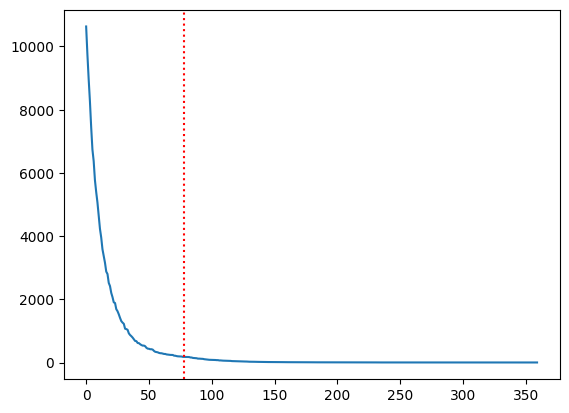

In [11]:
plt.plot(train['user_id'].value_counts().value_counts().to_dict().values())
plt.axvline(x=78, color='r', linestyle=':')
plt.show()

In [12]:
max_length = 78

lens = train['user_id'].value_counts()
pad_borders = pd.qcut(lens, 25, labels=False, retbins=True, duplicates='drop')[1]
pad_borders = np.append(pad_borders, 750).astype(int)
pad_borders.sort()
pad_borders = pad_borders[1:]
pad_borders

array([  20,   21,   22,   23,   24,   25,   26,   27,   28,   30,   31,
         32,   34,   36,   38,   41,   44,   48,   54,   62,   78,  750,
       6729])

In [14]:
lens_count = train['user_id'].value_counts().value_counts().sort_index()
keys = list(range(1, lens_count[lens_count.index <= max_length].index[-1] + 1))
values = []
for i in keys:
    for j in pad_borders:
        if j >= i:
            values.append(j)
            break

for i in range(1, len(pad_borders)):
    values += [pad_borders[i]] * (pad_borders[i] - pad_borders[i-1])
length_to_pad = dict(zip(keys, values))

with open('constants/buckets_info.pkl', 'wb') as f:
    pickle.dump(length_to_pad, f)

In [15]:
def pad_sequence(array, max_len):
    add_zeros = int(max_len - len(array[0]))
    return np.array([[-1] * add_zeros + list(x) for x in array])

def pad_labels(array, max_len):
    return [-1] * int(max_len - len(array)) + list(array)

def truncate(x, num_last=750):
    return x.values.transpose()[:, -num_last:].tolist()


def build_sequences(df, y, max_len, features, fixed_cols):
    out = df.groupby('user_id')[features] \
        .apply(lambda x: truncate(x, max_len)) \
        .reset_index().rename(columns={0: 'sequences'})
    out['fixed_cols'] = y[fixed_cols].values.tolist()
    out['labels'] = df.groupby('user_id')['interaction_type'] \
        .agg(lambda x: list(x.values[-max_len:]))
    out['video_ids'] = df.groupby('user_id')['video_id'] \
        .agg(lambda x: list(x.values[-max_len:]))
    out['sequence_length'] = out.sequences.apply(lambda x: len(x[1]))
    return out


def create_padded_buckets(frame, bucket_info, save_path=None):
    frame['bucket_idx'] = frame.sequence_length.map(bucket_info)
    result = {'padded_sequences': [], 'targets': [], 'user_id': [],
              'fixed_values': [], 'video_ids': []}

    for size, bucket in tqdm(frame.groupby('bucket_idx'), desc='Bucketing'):
        seqs = bucket.sequences.apply(lambda x: pad_sequence(x, size)).values
        result['padded_sequences'].append(np.array([np.array(x) for x in seqs]))
        result['targets'].append(bucket.labels.apply(lambda x: pad_labels(x, size)).values.tolist())
        result['user_id'].append(bucket.user_id.values)
        result['video_ids'].append(bucket.video_ids.apply(lambda x: pad_labels(x, size)).values.tolist())
        result['fixed_values'].append(bucket['fixed_cols'].values.tolist())

    frame.drop(columns=['bucket_idx'], inplace=True)
    if save_path:
        with open(save_path, 'wb') as f:
            pickle.dump(result, f)
    return result

train_seq = build_sequences(train, y_train, max_length, features, fixed_cols)

train_bucket = create_padded_buckets(train_seq, length_to_pad,
                                      save_path='save_data/chunk_train.pkl')
print('Data preprocessing complete!')

Bucketing:   0%|          | 0/21 [00:00<?, ?it/s]

Data preprocessing complete!


In [16]:
train_seq.head()

,user_id,sequences,fixed_cols,labels,video_ids,sequence_length
0,0,"[[-0.409887857611167, -0.24574371936850198, -0...","[1.0, -0.38366947376982913, 1.0, -1.2882151740...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[19283, 35680, 28549, 2595, 8720, 13523, 1933,...",21
1,1,"[[-1.1403603655913332, -1.4577708488454528, -0...","[1.0, 0.6314439645020888, 1.0, -1.288215174050...","[1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, ...","[964, 629, 2052, 733, 29, 6574, 6820, 1818, 14...",26
2,2,"[[-1.4575355615074177, 0.9659484098838824, -0....","[1.0, 0.4468778848162856, 1.0, -1.288215174050...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[71, 23284, 86, 36, 229, 1043, 1534, 1091, 90,...",21
3,3,"[[-0.7504114657476038, -0.13551259823888456, 1...","[1.0, 0.4468778848162856, 1.0, -1.288215174050...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1602, 1506, 303, 225, 192, 295, 460, 4420, 24...",31
4,4,"[[-0.6270835006939499, -0.6270835006939499, -0...","[1.0, 0.4468778848162856, 1.0, -1.288215174050...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, ...","[153774, 76572, 18635, 1747, 31536, 762, 10159...",27


In [17]:
with open('constants/features.pickle', 'rb') as f:
    di_features = pickle.load(f)

num_cols = di_features['num_cols']
cat_cols = di_features['cat_cols']
features = di_features['features']
num_fixed_cols = di_features['num_fixed_cols']
cat_fixed_cols = di_features['cat_fixed_cols']
fixed_cols = di_features['fixed_cols']

with open('constants/uniques.pkl', 'rb') as f:
    uniques = pickle.load(f)

In [20]:
def compute_embed_dim(n_cat):
    return min(600, round(1.6*n_cat**0.56))

embedding_projection = {}
for feat in cat_cols:
    n = max(uniques[feat]) + 1
    embedding_projection[feat] = (n, compute_embed_dim(n))
# 'owner_id': (7695, 240) --> (7695, 20)
# 'city_id_train': (554, 55) --> (554, 20)

owner_count = len(train.merge(video, on='video_id', how='left')['owner_id'].unique()) # 7695
city_сount = len(train.merge(video, on='video_id', how='left')['city_id'].unique()) # 554
embedding_projection['owner_id'] = (7695, 20)
embedding_projection['city_id_train'] = (554, 10)
del train

Prepare bathces

In [21]:
def batches_generator(paths, batch_size, features, shuffle=True, device=None, is_train=True):
    for path in paths:
        with open(path, 'rb') as f:
            data = pickle.load(f)
        seqs, targets = data['padded_sequences'], data['targets']
        fixed, vids, uids = data['fixed_values'], data['video_ids'], data['user_id']
        indices = np.arange(len(uids))

        if shuffle:
            np.random.shuffle(indices)
            seqs = [seqs[i] for i in indices]
            targets = [targets[i] for i in indices]
            fixed = [fixed[i] for i in indices]
            uids = [uids[i] for i in indices]
            vids = [vids[i] for i in indices]

        for idx in range(len(uids)):
            bucket_seqs, bucket_fixed = seqs[idx], fixed[idx]
            bucket_vids, bucket_uids = vids[idx], uids[idx]
            bucket_targets = targets[idx] if is_train else None

            for j in range(0, len(bucket_seqs), batch_size):
                bs = bucket_seqs[j:j+batch_size]
                bv = bucket_vids[j:j+batch_size]
                bf = bucket_fixed[j:j+batch_size]
                bu = bucket_uids[j:j+batch_size]
                # преобразуем в тензор каждую фичу отдельно так как у фичей разные типы данных
                bt = [torch.tensor(bs[:, i]).to(device) for i in range(len(features))]

                out = {
                    'video_ids': torch.tensor(bv).to(device),
                    'transactions_features': torch.stack(bt).permute(1, 0, 2),
                    'fixed_values': torch.tensor(bf).to(device),
                    'app_id': bu,
                }
                if is_train:
                    out['labels'] = torch.tensor(bucket_targets[j:j+batch_size]).to(device)
                yield out

Model

In [32]:
class RecSysLSTM(nn.Module):
    """
    embedding_projection - cловарь с размерностями ембеддингов для категориальных фичей
    categoric_cols - категориальные фичи
    numeric_cols - числовые фичи
    fixed_cols - фиксированные фичи для user
    """
    def __init__(self, vocab_size, embedding_projection, categoric_cols, numeric_cols, fixed_cols,
                 embed_dim=16, numeric_out=20, fixed_out=20, hidden_size=32, num_layers=1):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.item_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.categorical_embedding = nn.ModuleList(
            nn.Embedding(embedding_projection[f][0] + 1, embedding_projection[f][1]) # +1 - для паддинга
            for f in categoric_cols
        )
        categorical_embedding_total = sum(embedding_projection[f][1] for f in categoric_cols)

        self.num_layer = nn.Linear(len(numeric_cols), numeric_out)

        self.lstm = nn.LSTM(
            input_size  = embed_dim + numeric_out + categorical_embedding_total,
            num_layers  = self.num_layers,
            hidden_size = self.hidden_size,
            batch_first = True
        )

        self.fix_layer = nn.Linear(len(fixed_cols), fixed_out) # [B, fixed_out]

        self.dp1 = nn.Dropout(p=0.25)
        self.dp2 = nn.Dropout(p=0.25)

        self.fc = nn.Linear(hidden_size + fixed_out, vocab_size)

    def forward(self, item_ids, num_values, cat_values, fixed_values, h0, c0):
        # [B, L] -> [B, L, embed_dim]
        item = self.item_embedding(item_ids + 1) # иднекс паддинга '-1' --> '0'

        cat  = [emb(cat_values[:, i] + 1) for i, emb in enumerate(self.categorical_embedding)]
        cat  = torch.cat(cat, dim=-1) # [B, L, cat_dim]

        num  = self.num_layer(num_values.permute(0, 2, 1).float()) # [B, L, num_dim]

        # Конкатенация всех dynamic фичей: [B, L, hidden_size]
        x = torch.cat([item, cat, num], dim=-1)
        x = self.dp1(x)

        out, (h_n, c_n) = self.lstm(x, (h0, c0))
        out = torch.mean(out, dim=1) # [B, L, hidden_size] --> [B, hidden_size]

        fixed = self.fix_layer(fixed_values.float()) # [B, len(fixed_cols)] --> [B, fixed_out]
        out = torch.cat([out, fixed], dim=-1) # [B, fixed_out + hidden_size]
        out = self.dp2(out)

        out = self.fc(out)

        return out, h_n, c_n

    def init_hidden(self, batch_size, device):
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        return h0, c0

### Weighted Loss

**Метрика соревнования:** `satisfaction = views + 10 * likes`

Чтобы модель фокусировалась на лайках, используется weighted cross-entropy:
- Для `view` (label=1): вес = 1^3 = **1**
- Для `like` (label=2): вес = 2^3 = **8**

Куб (`label^3`) -- эвристически подобранная функция, чтобы лайки весили значительно больше.

In [33]:
criterion = nn.CrossEntropyLoss(reduction='none') # <-- без усреднения !!

def weighted_loss(preds, targets, weights):
    return (criterion(preds, targets) * weights).mean()

**Двухфазное обучение:**

| Фаза | Эпох | Что предсказываем | Зачем |
|------|------|-------------------|-------|
| 1 | 6 | Для длинных (>=30): 11-е с конца. Для коротких: последнее | Расширяет обучающую выборку, учит общие паттерны |
| 2 | 4 | Всегда последнее | Fine-tune на финальную задачу |

**Почему 11-е с конца в фазе 1?** Потому что последние 10 элементов используются для валидации (имитация top-10 рекомендаций). Модель учится предсказывать видео чуть раньше конца -- это даёт ей больше контекста для обобщения.

In [34]:
BATCH_SIZE = 256
LEARNING_RATE = 3e-3 / 5  # = 6e-4
EPOCHS_PHASE1 = 6
EPOCHS_PHASE2 = 4

vocab_size = max(uniques['video_id']) + 2  # +1 для padding, +1 для нумерации с 0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = RecSysLSTM(vocab_size, embedding_projection, cat_cols, num_cols, fixed_cols).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f'Vocab size: {vocab_size}, Device: {device}')
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Vocab size: 228507, Device: cuda
Model parameters: 15,939,513


In [35]:
model

RecSysLSTM(
  (item_embedding): Embedding(228507, 16, padding_idx=0)
  (categorical_embedding): ModuleList(
    (0): Embedding(7696, 20)
    (1): Embedding(555, 10)
  )
  (num_layer): Linear(in_features=5, out_features=20, bias=True)
  (lstm): LSTM(66, 32, batch_first=True)
  (fix_layer): Linear(in_features=6, out_features=20, bias=True)
  (dp1): Dropout(p=0.25, inplace=False)
  (dp2): Dropout(p=0.25, inplace=False)
  (fc): Linear(in_features=52, out_features=228507, bias=True)
)

In [38]:
os.makedirs('checkpoints', exist_ok=True)
seed_everything(42)
# ФАЗА 1
# Для длинных последовательностей: предсказываем 11-е видео с конца
# Для коротких: предсказываем последнее
print('=== Phase 1: Warm-up training ===')
model.train()
for epoch in range(EPOCHS_PHASE1):
    dataloader = batches_generator(['save_data/chunk_train.pkl'],
                                   batch_size=BATCH_SIZE, features=features, device=device)
    for step, batch in enumerate(tqdm(dataloader, desc=f'Phase1 Epoch {epoch}')):
        video_ids = batch['video_ids']
        trans = batch['transactions_features']
        fixed = batch['fixed_values']
        labels = batch['labels']

        if batch['app_id'].shape[0] != BATCH_SIZE:
            continue  # пропускаем неполные батчи

        h0, c0 = model.init_hidden(BATCH_SIZE, device)
        num_vals = trans[:, :len(num_cols)]
        cat_vals = trans[:, len(num_cols):].long()
        seq_len = trans.shape[-1]

        optimizer.zero_grad()

        if seq_len >= 30:
            c = seq_len - 11  # предсказываем 11-е с конца
        else:
            c = seq_len - 1   # предсказываем последнее

        # One-hot target
        target = torch.zeros((BATCH_SlIZE, vocab_size), device=device)
        target[torch.arange(BATCH_SIZE), video_ids[:, c]] = 1

        # передаём fixed (все 6 фичей), а не num_fixed (только 4)
        pred, _, _ = model(video_ids[:, :c], num_vals[:, :, :c], cat_vals[:, :, :c],
                           fixed, h0, c0)
        loss = weighted_loss(pred, target, labels[:, c] ** 3)

        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(f'  Step {step}, Loss: {loss.item()/seq_len:.4f}')

print('Phase 1 complete!')

=== Phase 1: Warm-up training ===


Phase1 Epoch 0: 0it [00:00, ?it/s]

  Step 0, Loss: 50.0940
  Step 100, Loss: 29.4229
  Step 200, Loss: 22.0154
  Step 300, Loss: 19.1435
  Step 400, Loss: 4.6261
  Step 500, Loss: 4.3482
  Step 600, Loss: 2.1847


Phase1 Epoch 1: 0it [00:00, ?it/s]

  Step 0, Loss: 1.5933
  Step 100, Loss: 1.8695
  Step 200, Loss: 0.6656
  Step 300, Loss: 0.8135
  Step 500, Loss: 0.6113
  Step 600, Loss: 0.8035


...

  Step 0, Loss: 0.6977
  Step 100, Loss: 0.9858
  Step 200, Loss: 0.7033
  Step 300, Loss: 0.4838
  Step 400, Loss: 0.3425
  Step 500, Loss: 0.6267
  Step 600, Loss: 0.7298


Phase1 Epoch 4: 0it [00:00, ?it/s]

  Step 0, Loss: 0.8148
  Step 100, Loss: 0.8109
  Step 200, Loss: 0.4904
  Step 300, Loss: 0.8343
  Step 400, Loss: 0.6702
  Step 500, Loss: 0.3524
  Step 600, Loss: 0.2700


Phase1 Epoch 5: 0it [00:00, ?it/s]

  Step 0, Loss: 0.7178
  Step 100, Loss: 0.2741
  Step 200, Loss: 0.6887
  Step 300, Loss: 0.4986
  Step 500, Loss: 0.3791
  Step 600, Loss: 0.3828
Phase 1 complete!


In [39]:
# ФАЗА 2
# Всегда предсказываем последнее видео (fine-tune)
print('=== Phase 2: Fine-tuning ===')
seed_everything(41)
model.train()
for epoch in range(EPOCHS_PHASE2):
    dataloader = batches_generator(['save_data/chunk_train.pkl'],
                                   batch_size=BATCH_SIZE, features=features, device=device)
    for step, batch in enumerate(tqdm(dataloader, desc=f'Phase2 Epoch {epoch}')):
        video_ids = batch['video_ids']
        trans = batch['transactions_features']
        fixed = batch['fixed_values']
        labels = batch['labels']

        if batch['app_id'].shape[0] != BATCH_SIZE:
            continue

        h0, c0 = model.init_hidden(BATCH_SIZE, device)
        num_vals = trans[:, :len(num_cols)]
        cat_vals = trans[:, len(num_cols):].long()
        seq_len = trans.shape[-1]

        optimizer.zero_grad()

        c = seq_len - 1  # всегда последнее
        target = torch.zeros((BATCH_SIZE, vocab_size), device=device)
        target[torch.arange(BATCH_SIZE), video_ids[:, c]] = 1

        # передаём fixed (все 6 фичей), а не num_fixed (только 4)
        pred, _, _ = model(video_ids[:, :c], num_vals[:, :, :c], cat_vals[:, :, :c],
                           fixed, h0, c0)
        loss = weighted_loss(pred, target, labels[:, c] ** 3)

        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(f'  Step {step}, Loss: {loss.item()/seq_len:.4f}')

print('Phase 2 complete!')
torch.save(model, 'checkpoints/model_final')

=== Phase 2: Fine-tuning ===


Phase2 Epoch 0: 0it [00:00, ?it/s]

  Step 0, Loss: 0.5504
  Step 100, Loss: 0.5817
  Step 200, Loss: 0.5321
  Step 300, Loss: 0.7045
  Step 400, Loss: 0.8575
  Step 500, Loss: 0.5952
  Step 600, Loss: 0.8768


Phase2 Epoch 1: 0it [00:00, ?it/s]

  Step 0, Loss: 0.5776
  Step 100, Loss: 0.6133
  Step 200, Loss: 0.7271
  Step 300, Loss: 0.7477
  Step 500, Loss: 0.5292
  Step 600, Loss: 0.3249


Phase2 Epoch 2: 0it [00:00, ?it/s]

  Step 0, Loss: 0.2912
  Step 100, Loss: 0.8693
  Step 200, Loss: 0.5113
  Step 300, Loss: 0.7029
  Step 400, Loss: 0.8000
  Step 500, Loss: 0.6456
  Step 600, Loss: 0.4847


Phase2 Epoch 3: 0it [00:00, ?it/s]

  Step 0, Loss: 0.6537
  Step 100, Loss: 0.5228
  Step 200, Loss: 0.7698
  Step 300, Loss: 0.2953
  Step 400, Loss: 0.5975
  Step 500, Loss: 0.3974
  Step 600, Loss: 0.4498
Phase 2 complete!


### Инференс

Для каждого пользователя:
1. Подаём всю его историю (кроме последнего элемента)
2. Берём top-10 предсказаний модели
3. Маппим индексы обратно в реальные video_id

In [42]:
model.eval()
dataloader = batches_generator(['save_data/chunk_train.pkl'],
                               batch_size=2048, features=features,
                               shuffle=False, device=device)

app_ids, predicted_labels = [], []

for batch in tqdm(dataloader, desc='Inference'):
    video_ids = batch['video_ids']
    trans = batch['transactions_features']
    fixed = batch['fixed_values']
    uid = batch['app_id']
    app_ids.extend(uid.tolist())

    bs = uid.shape[0]
    h0, c0 = model.init_hidden(bs, device)
    num_vals = trans[:, :len(num_cols)]
    cat_vals = trans[:, len(num_cols):].long()
    seq_len = trans.shape[-1]
    c = seq_len - 1

    with torch.no_grad():
        pred, _, _ = model(video_ids[:, :c], num_vals[:, :, :c], cat_vals[:, :, :c],
                           fixed, h0, c0) 

    top10 = torch.topk(pred, k=10).indices.cpu().numpy().tolist()
    predicted_labels.extend(top10)

print(f'Predictions for {len(app_ids)} users')

Inference: 0it [00:00, ?it/s]

Predictions for 152911 users


### Submission

In [44]:
with open('constants/map_video.pickle', 'rb') as f:
    map_video = pickle.load(f)
map_video_reverse = map_video['mav_values_reverse']

sample_submission = pd.read_csv(base_dir / 'sample_submission.csv')
labels_di = dict(zip(app_ids, predicted_labels))
preds_sorted = [labels_di[k] for k in sample_submission['user_id']]

sample_submission['recommendation'] = preds_sorted
sample_submission['recommendation'] = sample_submission['recommendation'].apply(
    lambda x: ' '.join(str(map_video_reverse[i]) for i in x)
)

sample_submission.to_csv('submission_best.csv', index=False)
print('Submission saved!')
sample_submission.head()

Submission saved!


,user_id,recommendation
0,938,101082 63190 34204 166282 45512 26721 12464 18...
1,57571,131005 63190 166282 26721 34204 101082 56158 2...
2,50873,91716 12860 64318 152563 127063 167186 96342 6...
3,4335,131005 101082 26721 57234 166282 169519 24671 ...
4,42138,189285 207349 105094 26721 24106 130482 101082...


# LSTM для рекомендательных систем: полный конспект
## На примере топ-1 решения NTO BDML 2024

---

## Оглавление

1. [Общая идея: зачем LSTM для рекомендаций](#1-общая-идея)
2. [Данные и задача](#2-данные-и-задача)
3. [Препроцессинг данных](#3-препроцессинг-данных)
   - 3.1 Frequency ID Encoding
   - 3.2 Типы фичей: Dynamic vs Static
   - 3.3 Нормализация
4. [Формирование последовательностей](#4-формирование-последовательностей)
   - 4.1 Группировка по пользователям
   - 4.2 Sequence Bucketing
   - 4.3 Padding
5. [Генерация батчей](#5-генерация-батчей)
   - 5.1 Зачем тензоризировать по фичам
   - 5.2 Permute
6. [Архитектура модели RecSysLSTM](#6-архитектура-модели)
   - 6.1 Embedding слои
   - 6.2 Linear для числовых фичей
   - 6.3 LSTM ядро
   - 6.4 Mean Pooling
   - 6.5 Fixed features
   - 6.6 Финальный классификатор
7. [Как работает LSTM внутри](#7-как-работает-lstm-внутри)
   - 7.1 Ячейка LSTM (cell)
   - 7.2 Forget Gate
   - 7.3 Input Gate
   - 7.4 Output Gate
   - 7.5 Пример на пальцах для RecSys
8. [Стратегия обучения](#8-стратегия-обучения)
   - 8.1 Weighted Cross-Entropy Loss
   - 8.2 Двухфазное обучение
   - 8.3 Гиперпараметры
9. [Инференс и submission](#9-инференс-и-submission)
10. [Полная схема размерностей](#10-полная-схема-размерностей)
11. [Ключевые приёмы и выводы](#11-ключевые-приёмы-и-выводы)

---

## 1. Общая идея

### Зачем LSTM для рекомендаций?

Классические рекомендательные системы (collaborative filtering, matrix factorization) рассматривают
взаимодействия пользователь-элемент как **неупорядоченное множество**. Они не учитывают **порядок**
взаимодействий.

Но в реальности последовательность важна:

```
Пользователь посмотрел: [Комедия] -> [Комедия] -> [Комедия] -> [Драма] -> [???]
```

Если человек 3 раза подряд смотрел комедии, а потом переключился на драму -- это **сигнал**.
Его текущие предпочтения сместились. Классическая модель этого не увидит, а LSTM -- увидит.

### Ключевая аналогия

LSTM изначально создан для обработки **последовательностей текста**. В NLP:
- Входная последовательность: слова в предложении
- Задача: предсказать следующее слово

В RecSys мы делаем **ровно то же самое**, но вместо слов -- видео:
- Входная последовательность: видео, которые пользователь посмотрел (в хронологическом порядке)
- Задача: предсказать следующее видео, которое ему понравится

```
NLP:    "Я люблю смотреть [???]"      --> предсказываем слово
RecSys: [video_1, video_2, video_3, ???] --> предсказываем video_id
```

### Почему именно LSTM, а не обычная RNN?

Обычная RNN страдает от проблемы **затухающего градиента**: при длинных последовательностях
она "забывает" ранние элементы. LSTM решает это с помощью **механизма гейтов** (ворот):

- **Forget Gate** -- решает, что забыть из прошлого
- **Input Gate** -- решает, что запомнить из нового
- **Output Gate** -- решает, что выдать на выход

Благодаря этому LSTM может помнить паттерны из далёкого прошлого:
"Пользователь месяц назад активно смотрел кулинарные видео, потом переключился на спорт,
но его долгосрочный интерес к кулинарии всё ещё хранится в памяти ячейки".


---

## 2. Данные и задача

### Задача соревнования

**Вход:** история взаимодействий 152,911 пользователей с 228,506 видео.
**Выход:** для каждого пользователя предсказать top-10 видео, которые ему понравятся.

### Метрика

```
satisfaction = views + 10 * likes
```

Лайки в 10 раз ценнее просмотров. Это критически важно для стратегии обучения (см. раздел 8).

### Таблицы данных

```
train.csv     -- 5,434,520 взаимодействий (user_id, video_id, interaction_type, timestamp)
video.csv     -- метаданные видео (duration, upload_timestamp, owner_id)
owner.csv     -- метаданные автора (subscribers_count, city_id, last_active_date)
user.csv      -- метаданные пользователя (age, gender, language, city_id, birth_city_id)
```

### Типы взаимодействий

```
interaction_type: 'view' (просмотр) --> кодируется как 1
interaction_type: 'like' (лайк)     --> кодируется как 2
```

---

## 3. Препроцессинг данных

### 3.1 Frequency ID Encoding

**Что это:** замена категориальных ID (video_id, owner_id, city_id) на новые индексы,
отсортированные **по частоте встречаемости**.

```python
un = train['video_id'].value_counts().index  # сортировка по убыванию частоты
map_values = dict(zip(un, range(len(un))))    # самый популярный = 0
train['video_id'] = train['video_id'].map(map_values)
```

**Пример:**
```
Исходные video_id:  [45123, 891, 2034, 891, 45123, 45123]
Частоты:            45123 встречается 3 раза, 891 -- 2 раза, 2034 -- 1 раз
После encoding:     45123 -> 0, 891 -> 1, 2034 -> 2
Результат:          [0, 1, 2, 1, 0, 0]
```

**Зачем:**
1. Самые популярные видео получают маленькие индексы -- это позволяет при необходимости
   отсечь редкие категории простым порогом `if idx > threshold`
2. Embedding таблица хранится в порядке частоты -- горячие элементы ближе друг к другу в памяти

**Для каких фичей делается frequency encoding:**
- `video_id` -- 228,506 уникальных значений
- `owner_id` -- 7,695 уникальных значений
- `city_id_train` (город автора) -- 554 уникальных значения

**Почему только для этих трёх, а не для всех?**
Потому что это **высококардинальные** категориальные фичи, которые пойдут в Embedding.
Остальные категориальные (gender, language) уже бинарные (0/1) -- для них encoding не нужен.

### 3.2 Типы фичей: Dynamic vs Static (Fixed)

Это **ключевое** архитектурное решение. Все фичи делятся на два типа:

```
┌─────────────────────────────────────────────────────────────────────┐
│                      DYNAMIC фичи                                  │
│  Меняются от видео к видео в последовательности                    │
│  Подаются в LSTM на КАЖДОМ временном шаге                          │
├─────────────────────┬───────────────────────────────────────────────┤
│  Числовые (num)     │ last_active_date     -- дата посл. активности│
│  5 штук             │ upload_timestamp     -- когда загружено видео│
│                     │ create_date_train    -- дата создания канала  │
│                     │ duration             -- длительность видео    │
│                     │ subscribers_count    -- подписчики автора     │
├─────────────────────┼───────────────────────────────────────────────┤
│  Категориальные     │ owner_id             -- автор видео           │
│  (cat) 2 штуки      │ city_id_train        -- город автора          │
└─────────────────────┴───────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│                      STATIC (FIXED) фичи                           │
│  Одинаковы для всех видео одного пользователя                      │
│  Подаются ПОСЛЕ LSTM, один раз на пользователя                     │
├─────────────────────┬───────────────────────────────────────────────┤
│  Числовые (num)     │ gender               -- пол (0/1)            │
│  4 штуки            │ age                  -- возраст              │
│                     │ language             -- язык (0/1)            │
│                     │ create_date_user     -- дата регистрации      │
├─────────────────────┼───────────────────────────────────────────────┤
│  Категориальные     │ city_id_user         -- город пользователя    │
│  2 штуки            │ birth_city_id        -- город рождения        │
└─────────────────────┴───────────────────────────────────────────────┘
```

**Почему важно это разделение?**

LSTM обрабатывает **последовательность**. Каждый шаг -- это одно видео с его контекстом.
Dynamic фичи **меняются на каждом шаге** (у каждого видео своя длительность, свой автор, своя дата).
Static фичи **одинаковы для всех шагов** (пол и возраст пользователя не меняются от видео к видео).

Подавать static фичи на каждом шаге LSTM -- это:
1. Бессмысленное расширение входного вектора (одна и та же информация на каждом шаге)
2. Лишняя нагрузка на обучение

Поэтому static фичи подаются **после LSTM** -- конкатенируются к итоговому представлению пользователя.

### 3.3 Нормализация

```python
ss = StandardScaler()
train[num_cols_raw + time_cols] = ss.fit_transform(train[num_cols_raw + time_cols])
```

StandardScaler приводит каждую числовую фичу к **среднему = 0, стандартному отклонению = 1**.

**Зачем:**
- Числовые фичи имеют разные масштабы: `duration` ~ [0, 1000], `subscribers_count` ~ [0, 1000000],
  `timestamp` ~ [1690000000000, 1700000000000]
- Без нормализации фичи с большими значениями будут доминировать в градиентах
- LSTM и Linear слои работают лучше с нормализованными данными

**Важно:** нормализуются только числовые фичи (`age`, `duration`, `subscribers_count`, все timestamp).
Категориальные фичи (ID) НЕ нормализуются -- они пойдут в Embedding.


---

## 4. Формирование последовательностей

### 4.1 Группировка по пользователям

Данные -- это плоская таблица взаимодействий. Нам нужно преобразовать её в **последовательности по пользователям**:

```
Плоская таблица:                        Последовательности:
user_id  video_id  timestamp            user_0: [video_5, video_2, video_8, video_1]
0        5         100                  user_1: [video_3, video_7]
0        2         200                  user_2: [video_6, video_4, video_9]
0        8         300
0        1         400
1        3         150
1        7         250
...
```

Каждая последовательность сортируется по `timestamp` -- хронологический порядок.
Для каждого видео в последовательности сохраняются все dynamic фичи.

**Структура одной последовательности:**

```
User 0:
  sequences: [[feat_0 для каждого видео],   # last_active_date
              [feat_1 для каждого видео],   # upload_timestamp
              [feat_2 для каждого видео],   # create_date_train
              [feat_3 для каждого видео],   # duration (нормализованное)
              [feat_4 для каждого видео],   # subscribers_count (нормализованное)
              [feat_5 для каждого видео],   # owner_id (целые числа)
              [feat_6 для каждого видео]]   # city_id_train (целые числа)
  fixed_cols: [gender, age, language, create_date_user, city_id_user, birth_city_id]
  labels: [1, 1, 2, 1, ...]  # interaction_type для каждого видео
  video_ids: [5, 2, 8, 1, ...]  # video_id для каждого видео
```

**Формат sequences:** `[num_features, seq_len]` -- 7 фичей x длина последовательности.

### 4.2 Sequence Bucketing

**Проблема:** пользователи имеют разное количество взаимодействий. Кто-то посмотрел 5 видео,
кто-то -- 500. LSTM в PyTorch при использовании `batch_first=True` требует, чтобы все
последовательности в батче имели **одинаковую длину**.

**Наивное решение:** паддить все последовательности до максимальной длины (750).
Для пользователя с 5 видео это 745 бессмысленных нулей. Огромный расход памяти и вычислений.

**Sequence Bucketing -- элегантное решение:**

1. Определяем **границы бакетов** через квантили распределения длин:
```python
pad_borders = pd.qcut(lens, 25, labels=False, retbins=True, duplicates='drop')[1]
# Результат: [20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 32, 34, 36, 38, 41, 44, 48, 54, 62, 78, 750, 6729]
```

2. Каждый пользователь попадает в **ближайший бакет сверху**:
```
Длина 5  --> бакет 20  (паддим до 20 -- 15 нулей)
Длина 19 --> бакет 20  (паддим до 20 -- 1 ноль)
Длина 25 --> бакет 25  (паддим до 25 -- 0 нулей)
Длина 35 --> бакет 36  (паддим до 36 -- 1 ноль)
Длина 200 -> бакет 750 (паддим до 750 -- для длинных)
```

3. **Внутри каждого бакета** все последовательности паддятся до длины бакета.

**Почему квантили, а не равномерная разбивка?**
Квантили гарантируют, что в каждом бакете **примерно одинаковое число пользователей**.
Это обеспечивает равномерную загрузку GPU при обучении.

**Зачем число 750 в pad_borders?**
750 -- это максимальная длина, до которой обрезаются (truncate) все последовательности.
Квантили рассчитываются только для "нормальных" длин (до max_length=78).
Пользователи с длинами > 78 попадают в бакет 750. Добавление 750 в pad_borders
гарантирует, что для них тоже есть бакет.

### 4.3 Padding

Паддинг заполняет **значением -1** начало последовательности (left-padding):

```python
def pad_sequence(array, max_len):
    add_zeros = int(max_len - len(array[0]))
    return np.array([[-1] * add_zeros + list(x) for x in array])
```

**Почему -1, а не 0?**
Потому что 0 -- это валидный индекс (самое популярное видео после frequency encoding).
Значение -1 однозначно указывает на "пустое место".

**Почему LEFT padding (слева), а не справа?**
```
Left padding:  [-1, -1, -1, video_1, video_2, video_3]
Right padding: [video_1, video_2, video_3, -1, -1, -1]
```

При left padding реальные данные оказываются **в конце** последовательности.
LSTM обрабатывает слева направо, поэтому:
- Сначала проходит по паддингу (не несёт информации)
- Потом по реальным данным
- **Последнее скрытое состояние** содержит информацию о реальных данных

Это важно, потому что при предсказании нас интересует именно последнее состояние.

**Как модель обрабатывает паддинг (-1)?**

В forward методе:
```python
item = self.item_embedding(item_ids + 1)  # -1 + 1 = 0 -> padding_idx=0
cat  = [emb(cat_values[:, i] + 1) for i, emb in enumerate(self.categorical_embedding)]
```

Прибавление `+1` сдвигает все индексы:
- Паддинг `-1` становится `0` -- это `padding_idx`, для которого Embedding возвращает нулевой вектор
- Валидный ID `0` становится `1`
- Валидный ID `k` становится `k+1`

Таким образом, на позициях паддинга LSTM получает **нулевой входной вектор** -- он не вносит
информации в скрытое состояние.


---

## 5. Генерация батчей

### Как устроен batches_generator

Генератор загружает pickle-файл с бакетированными данными и выдаёт батчи:

```
pickle файл содержит:
  padded_sequences[0]: numpy array (N_users_in_bucket, 7_features, bucket_length)
  padded_sequences[1]: numpy array для другого бакета
  ...
  targets[0]: list of lists (метки для каждого бакета)
  fixed_values[0]: list of lists (фиксированные фичи)
  video_ids[0]: list of lists
  user_id[0]: numpy array
```

Для каждого бакета:
1. Берём порцию из `batch_size` пользователей (bs)
2. Тензоризируем `bs` **по фичам отдельно**
3. Делаем `stack` + `permute`

### 5.1 Зачем тензоризировать по фичам отдельно

```python
bt = [torch.tensor(bs[:, i]).to(device) for i in range(len(features))]
```

**Зачем нельзя просто `torch.tensor(bs)`?**

Потому что в массиве `bs` смешаны **разные типы данных**:
- Фичи 0-4 (числовые): float64 (-1.23, 0.45, 2.31, ...)
- Фичи 5-6 (категориальные): int (0, 1, 2, 3, ...)

Если сделать `torch.tensor(bs)`, PyTorch приведёт всё к одному типу.
Float и int в одном массиве --> всё станет float64.
Но для Embedding нужны **целые числа** (int/long).

Тензоризируя по фичам отдельно, мы сохраняем правильные типы:
```
bt[0] = torch.tensor(bs[:, 0])  # float -- last_active_date
bt[1] = torch.tensor(bs[:, 1])  # float -- upload_timestamp
...
bt[5] = torch.tensor(bs[:, 5])  # float, но содержит целые числа (owner_id)
bt[6] = torch.tensor(bs[:, 6])  # float, но содержит целые числа (city_id_train)
```

### 5.2 Permute: зачем и как

```python
transactions_features = torch.stack(bt).permute(1, 0, 2)
```

**Шаг 1: `torch.stack(bt)`**
```
bt -- это list из 7 тензоров, каждый формы (B, L)
stack собирает их в один тензор: (7, B, L)
                                  ^-- ось фичей первая
```

**Шаг 2: `.permute(1, 0, 2)`**
```
(7, B, L) --> (B, 7, L)
 ^  ^  ^       ^  ^  ^
 0  1  2       1  0  2  -- переставили оси 0 и 1
```

Теперь тензор имеет форму `(B, num_features, seq_len)` -- **батч первый**,
что удобно для дальнейшей работы: `trans[:, :5]` берёт числовые фичи,
`trans[:, 5:]` берёт категориальные.


---

## 6. Архитектура модели RecSysLSTM

### Полная схема

```
                    ВХОД (один батч, один бакет)
                    ════════════════════════════
                    video_ids:    (B, L)        -- какие видео смотрел
                    num_values:   (B, 5, L)     -- 5 числовых dynamic фичей
                    cat_values:   (B, 2, L)     -- 2 категориальные dynamic фичи
                    fixed_values: (B, 6)        -- 6 static фичей пользователя

         ┌──────────────┐  ┌──────────────┐  ┌──────────────────┐
         │ video_ids     │  │ cat_values   │  │ num_values       │
         │ (B, L)        │  │ (B, 2, L)    │  │ (B, 5, L)        │
         └──────┬───────┘  └──────┬───────┘  └──────┬───────────┘
                │ +1              │ +1               │
                │ Embedding      │ Embedding x2     │ permute(0,2,1)
                │ (228507, 16)   │ (7696,20)        │ --> (B, L, 5)
                │                │ (555, 10)        │ Linear(5, 20)
                ▼                ▼                  ▼
          (B, L, 16)      (B, L, 30)         (B, L, 20)
                │                │                  │
                └────────┬───────┘──────────────────┘
                         │ torch.cat(dim=-1)
                         ▼
                    (B, L, 66)        <-- 16 + 30 + 20 = 66
                         │
                    Dropout(0.25)
                         │
                    ┌────▼────┐
                    │  LSTM   │    input_size=66, hidden_size=32
                    │(B,L,32) │    batch_first=True
                    └────┬────┘
                         │
                    Mean Pooling    (B, L, 32) --> (B, 32)
                    по оси L       torch.mean(out, dim=1)
                         │
                         ├─────────────── fixed_values (B, 6)
                         │                      │
                         │                Linear(6, 20)
                         │                      │
                         │                 (B, 20)
                         │                      │
                         ├──────────────────────┘
                         │ torch.cat(dim=-1)
                         ▼
                    (B, 52)          <-- 32 + 20 = 52
                         │
                    Dropout(0.25)
                         │
                    Linear(52, 228507)
                         │
                         ▼
                    (B, 228507)      <-- логиты для каждого видео
```

### 6.1 Embedding слои

**Что такое Embedding?**

Embedding -- это **обучаемая таблица подстановки**. Для каждого уникального ID хранится вектор
фиксированной длины. Этот вектор обучается вместе с моделью.

```
Embedding(228507, 16):
  ID 0 --> [0.12, -0.34, 0.56, ..., 0.78]    # 16 чисел
  ID 1 --> [-0.23, 0.45, -0.67, ..., 0.11]
  ID 2 --> [0.89, -0.12, 0.34, ..., -0.56]
  ...
  ID 228506 --> [...]
```

При подаче батча видео-ID:
```
video_ids = [[5, 2, 8], [1, 3, 7]]    # (B=2, L=3)
            после lookup:
item_emb  = [[[emb_5], [emb_2], [emb_8]],    # (2, 3, 16)
             [[emb_1], [emb_3], [emb_7]]]
```

**Три Embedding слоя в модели:**

| Слой | Размер | Что кодирует |
|------|--------|-------------|
| `item_embedding` | (228507, 16) | video_id -- главный элемент |
| `categorical_embedding[0]` | (7696, 20) | owner_id -- автор видео |
| `categorical_embedding[1]` | (555, 10) | city_id_train -- город автора |

**Почему +1 в размере Embedding?**
```python
nn.Embedding(embedding_projection[f][0] + 1, ...)  # +1 для паддинга
```
ID -1 (паддинг) после сдвига +1 становится 0. Нужен дополнительный слот для этого нулевого индекса.

**Как подбирается размер embedding?**

Используется **формула FastAI**:
```python
embed_dim = min(600, round(1.6 * n_categories ** 0.56))
```

Где `n_categories` -- количество уникальных значений.

```
video_id:      228507 категорий --> min(600, 1.6 * 228507^0.56) = min(600, 1008) = 600
                                   Но автор вручную выбрал 16 (маленький, для скорости)
owner_id:      7695 категорий   --> min(600, 1.6 * 7695^0.56) = 240
                                   Автор вручную уменьшил до 20
city_id_train: 554 категории    --> min(600, 1.6 * 554^0.56) = 55
                                   Автор вручную уменьшил до 10
```

**Почему автор уменьшил размеры?**

Автоматическая формула даёт верхнюю границу. На практике:
1. Большие embedding = больше параметров = дольше обучение
2. При ограниченных данных большие embedding могут переобучиться
3. Маленькие embedding работают как **регуляризация**
4. Для owner_id и city_id информативность ниже, чем для video_id

**Почему количество категорий берётся из train merge, а не из полного датасета?**

```python
# Берётся из train merge, а не из owner.csv
owner_count = len(train.merge(video, on='video_id', how='left')['owner_id'].unique())  # 7695
```

Потому что в таблицах owner.csv и video.csv могут быть авторы/города, которые **НИ РАЗУ**
не встречаются в обучающих данных. Для них embedding никогда не обновится.
Из train merge мы берём только те категории, которые **реально встречаются** -- экономим память.

### 6.2 Linear для числовых фичей

```python
self.num_layer = nn.Linear(5, 20)
```

5 числовых dynamic фичей --> 20-мерное представление.

**Зачем Linear, а не подавать сырые числа?**

1. **Проекция в общее пространство:** числовые фичи (нормализованные) имеют диапазон ~[-3, 3].
   Embedding выдаёт векторы со случайными значениями. Linear позволяет числовым фичам
   "научиться" быть в том же пространстве, что и embedding.

2. **Нелинейность через обучение:** Linear слой находит **оптимальные комбинации** фичей.
   Например, может выучить, что `duration * subscribers_count` -- важный паттерн.

3. **Выравнивание размерностей:** 5 сырых чисел дают мало информации по сравнению с 30-мерным
   embedding. Linear(5, 20) расширяет числовые фичи до сопоставимой размерности.

**Важный момент с permute:**

```python
num = self.num_layer(num_values.permute(0, 2, 1).float())
```

`num_values` приходит как `(B, 5, L)` -- 5 фичей, L шагов.
Но `Linear(5, 20)` работает по **последней** оси.
`.permute(0, 2, 1)` переставляет в `(B, L, 5)` -- теперь последняя ось = 5 фичей.
После Linear: `(B, L, 20)`.

### 6.3 LSTM ядро

```python
self.lstm = nn.LSTM(
    input_size  = 66,       # 16 (item) + 30 (cat) + 20 (num) = 66
    hidden_size = 32,       # размер скрытого состояния
    num_layers  = 1,        # один слой LSTM
    batch_first = True      # первая ось -- батч
)
```

**input_size = 66:** на каждом шаге LSTM получает вектор из 66 чисел -- конкатенацию
всех представлений одного видео:
- 16 чисел от item_embedding (что за видео)
- 20 чисел от owner_embedding (кто автор)
- 10 чисел от city_embedding (откуда автор)
- 20 чисел от num_layer (числовые характеристики видео)

**hidden_size = 32:** LSTM на каждом шаге хранит и обновляет вектор из 32 чисел --
это "память" о всём, что модель видела до текущего шага.

**batch_first = True:** тензоры имеют форму `(B, L, features)`, а не `(L, B, features)`.

**Вход и выход LSTM:**
```
Вход:  x      = (B, L, 66)     -- L шагов, 66 признаков на каждом
       (h0, c0) = (1, B, 32)   -- начальное скрытое состояние (нули)
Выход: output = (B, L, 32)     -- скрытые состояния на КАЖДОМ шаге
       h_n    = (1, B, 32)     -- последнее скрытое состояние
       c_n    = (1, B, 32)     -- последнее состояние ячейки
```

### 6.4 Mean Pooling

```python
out = torch.mean(out, dim=1)  # (B, L, 32) --> (B, 32)
```

LSTM выдаёт скрытое состояние на **каждом** шаге: `(B, L, 32)`.
Mean Pooling усредняет все L шагов в один вектор: `(B, 32)`.

**Почему Mean Pooling, а не просто последнее скрытое состояние (h_n)?**

```
Последнее h_n:  берём только h_L -- информация только с последнего шага
                (она содержит информацию о всей последовательности, но
                 с акцентом на последние элементы)

Mean Pooling:   усредняем h_1, h_2, ..., h_L -- каждый шаг вносит вклад
                (более сбалансированное представление)
```

Mean Pooling лучше потому что:
1. Не зависит от длины последовательности (усреднение нормализует)
2. Учитывает **все** видео в истории, а не только последние
3. Более устойчив к шуму (один плохой шаг не испортит всё представление)
4. Работает лучше с left-padding (первые шаги с нулевым входом дают маленький вклад)

### 6.5 Fixed features

```python
fixed = self.fix_layer(fixed_values.float())  # (B, 6) --> (B, 20)
out = torch.cat([out, fixed], dim=-1)          # (B, 32) + (B, 20) = (B, 52)
```

6 статических фичей пользователя (пол, возраст, язык, дата регистрации, город, город рождения)
проецируются через Linear(6, 20) в 20-мерное пространство.

Затем конкатенируются с LSTM-представлением пользователя:
```
[что пользователь смотрел (32)] + [кто этот пользователь (20)] = [полное представление (52)]
```

### 6.6 Финальный классификатор

```python
self.fc = nn.Linear(52, 228507)  # 52 --> vocab_size
```

52-мерное представление пользователя проецируется в пространство размером с **весь словарь видео**.
Каждый выходной нейрон соответствует одному видео.

Выход: `(B, 228507)` -- **логиты** (ненормализованные вероятности) для каждого видео.

```
Выход = [0.12, -0.34, 2.56, 0.01, ..., -0.78]
          ^      ^      ^
         video_0 video_1 video_2  ...  video_228506

Самое большое значение = рекомендация.
```

Это аналогично задаче **классификации с 228,507 классами** -- на каждом обучающем примере
мы знаем правильный video_id и хотим, чтобы его логит был максимальным.


---

## 7. Как работает LSTM внутри

### 7.1 Общая картина

LSTM обрабатывает последовательность **шаг за шагом**. На каждом шаге t:

```
Шаг t:
  Вход:    x_t     -- вектор текущего элемента (66 чисел)
           h_{t-1} -- скрытое состояние с прошлого шага (32 числа)
           c_{t-1} -- состояние ячейки с прошлого шага (32 числа)
  Выход:   h_t     -- новое скрытое состояние (32 числа)
           c_t     -- новое состояние ячейки (32 числа)
```

**Два вида памяти:**
- `h_t` (hidden state) -- **краткосрочная память**, то что LSTM "говорит" наружу
- `c_t` (cell state) -- **долгосрочная память**, внутреннее хранилище

### 7.2 Forget Gate (Ворота забывания)

```
f_t = sigmoid(W_f * [h_{t-1}, x_t] + b_f)
```

Forget gate решает: **какую часть долгосрочной памяти забыть?**

- sigmoid выдаёт числа от 0 до 1 для каждого из 32 нейронов
- 0 = "полностью забыть этот нейрон"
- 1 = "полностью запомнить"
- 0.5 = "запомнить наполовину"

**Пример для RecSys:**
```
Пользователь долго смотрел комедии, потом переключился на документалки.
Forget gate начинает "забывать" паттерн "любитель комедий" и
освобождает место для нового паттерна.
```

### 7.3 Input Gate (Ворота входа)

```
i_t = sigmoid(W_i * [h_{t-1}, x_t] + b_i)     -- что обновить?
C̃_t = tanh(W_C * [h_{t-1}, x_t] + b_C)       -- какие новые значения?

c_t = f_t * c_{t-1} + i_t * C̃_t               -- обновление памяти
```

Input gate состоит из двух частей:
1. `i_t` -- **какие нейроны памяти обновить** (sigmoid, от 0 до 1)
2. `C̃_t` -- **какие новые значения записать** (tanh, от -1 до 1)

Обновление памяти:
```
c_t = (забыть часть старого) + (записать часть нового)
c_t = f_t * c_{t-1}          + i_t * C̃_t
```

**Пример для RecSys:**
```
Текущее видео -- от популярного автора с 500K подписчиков.
Input gate решает: "Запомнить, что пользователь интересуется контентом от крупных авторов".
Это записывается в cell state.
```

### 7.4 Output Gate (Ворота выхода)

```
o_t = sigmoid(W_o * [h_{t-1}, x_t] + b_o)
h_t = o_t * tanh(c_t)
```

Output gate решает: **какую часть долгосрочной памяти показать на выходе**.

Cell state (c_t) хранит ВСЮ информацию. Но не вся она нужна прямо сейчас.
Output gate фильтрует: "для предсказания следующего видео, какая часть моей памяти релевантна?"

**Пример для RecSys:**
```
Cell state помнит: "любит комедии", "предпочитает короткие видео", "интересуется кулинарией".
Если последние 3 видео были кулинарные, output gate выдаст h_t с акцентом на
"кулинарию" и "короткие видео", приглушив "комедии" -- сейчас они менее релевантны.
```

### 7.5 Пример на пальцах для RecSys

Рассмотрим обработку последовательности из 4 видео:

```
Шаг 0 (паддинг, x_0 = нулевой вектор):
  f_0 ≈ 0.5 (забыть наполовину -- но забывать нечего, c_{-1} = 0)
  i_0 ≈ 0.5 (записать наполовину -- но входа нет, x_0 = 0)
  c_0 ≈ 0   (память почти пуста)
  h_0 ≈ 0   (выход почти нулевой)
  --> Паддинг не вносит информации ✓

Шаг 1 (первое реальное видео: короткая комедия, x_1 = [embed_comedy, dur=0.3, ...]):
  f_1 ≈ 0.9 (почти всё сохранить -- терять нечего)
  i_1 ≈ 0.8 (запомнить много -- новая информация)
  c_1: записали "комедия, короткое видео, молодой автор"
  h_1: выдали "текущий контекст = комедия"

Шаг 2 (второе видео: короткая комедия от другого автора, x_2 = [embed_comedy2, ...]):
  f_2 ≈ 0.95 (почти всё сохранить -- подтверждение паттерна)
  i_2 ≈ 0.7  (усилить паттерн "короткая комедия")
  c_2: усилился паттерн "любит короткие комедии"
  h_2: "уверенный любитель коротких комедий"

Шаг 3 (третье видео: длинный документальный фильм, x_3 = [embed_doc, dur=2.5, ...]):
  f_3 ≈ 0.6 (забыть часть "только комедии" -- появилось новое)
  i_3 ≈ 0.8 (запомнить "документалки тоже интересны")
  c_3: смесь "комедии" + "документалки", но комедии ослабли
  h_3: "текущий интерес смещается к документалкам"

Mean Pooling: (h_0 + h_1 + h_2 + h_3) / 4
  --> Сбалансированное представление: "преимущественно комедии, но интересуется и документалками"
```

### Количество параметров LSTM

Для одного слоя LSTM с input_size=66 и hidden_size=32:

```
Каждые gate (f, i, o) и кандидат (C̃) -- это отдельный Linear:
  W * [h_{t-1}, x_t] + b
  Размер W: (hidden_size, input_size + hidden_size) = (32, 66+32) = (32, 98)
  Размер b: (32,)

4 таких Linear (forget, input, output, candidate):
  4 * (32 * 98 + 32) = 4 * (3136 + 32) = 4 * 3168 = 12,672 параметров
```


---

## 8. Стратегия обучения

### 8.1 Weighted Cross-Entropy Loss

**Задача оптимизации:** модель выдаёт логиты для 228,507 видео. Мы знаем правильный ответ
(video_id, который пользователь реально посмотрел/лайкнул). Cross-Entropy Loss максимизирует
вероятность правильного видео.

**Проблема:** метрика соревнования `satisfaction = views + 10 * likes`.
Лайки в 10 раз ценнее! Но стандартный CrossEntropyLoss не различает views и likes --
для него все ошибки одинаковы.

**Решение -- weighted loss:**

```python
criterion = nn.CrossEntropyLoss(reduction='none')  # БЕЗ усреднения!

def weighted_loss(preds, targets, weights):
    return (criterion(preds, targets) * weights).mean()
```

**Как работают веса:**

```python
weights = labels[:, c] ** 3   # label в кубе
```

```
Для view (label=1): вес = 1^3 = 1   -- обычная ошибка
Для like (label=2): вес = 2^3 = 8   -- ошибка в 8 раз дороже
```

Модель получает **в 8 раз больший градиент** от неправильного предсказания лайкнутого видео.
Это заставляет модель особенно стараться предсказывать именно те видео, которые пользователь
ЛАЙКНУЛ, а не просто посмотрел.

**Почему куб, а не множитель 10?**
`label^3` -- эвристически подобранная функция. Куб даёт соотношение 1:8,
что близко к 1:10 в метрике, но немного мягче. Точное значение подбирается экспериментально.

**Формат target:**

```python
target = torch.zeros((BATCH_SIZE, vocab_size), device=device)
target[torch.arange(BATCH_SIZE), video_ids[:, c]] = 1
```

Target -- это **one-hot вектор** размера 228,507: все нули, кроме единицы на позиции
правильного video_id. CrossEntropyLoss сравнивает логиты модели с этим вектором.

### 8.2 Двухфазное обучение

Это **ключевой приём** данного решения.

#### Фаза 1: Warm-up (6 эпох)

```python
if seq_len >= 30:
    c = seq_len - 11  # предсказываем 11-е видео С КОНЦА
else:
    c = seq_len - 1   # для коротких -- последнее
```

**Что происходит:**
Для длинных последовательностей (>=30 элементов) модель предсказывает **не последнее** видео,
а **11-е с конца**.

```
Последовательность: [v1, v2, v3, ..., v20, v21, v22, ..., v30]
                                            ↑
                                     предсказываем это (11-е с конца)
                     ├─── входная история ───┤├── не используется ──┤
```

**Зачем это?**

1. **Больше обучающих примеров:** для длинных последовательностей мы используем "более ранний"
   таргет. Это как будто у нас дополнительный обучающий пример для того же пользователя.

2. **Имитация реальной задачи:** в реальности мы предсказываем будущее на основе прошлого.
   Предсказание 11-го с конца -- это та же задача, но "отмотанная назад".

3. **Почему именно 11-е, а не 5-е или 20-е?**
   Потому что на инференсе мы предсказываем **top-10** видео. Если мы обучаем модель
   предсказывать 11-е с конца, последние 10 элементов играют роль "валидационного set" --
   мы проверяем, попадает ли наше предсказание в эти 10.

#### Фаза 2: Fine-tuning (4 эпохи)

```python
c = seq_len - 1  # всегда предсказываем последнее
```

**Что происходит:**
Модель переключается на предсказание **последнего** видео -- ровно то,
что нужно на инференсе.

**Зачем две фазы, а не сразу fine-tune?**

Фаза 1 "прогревает" модель на расширенных данных. Модель учит общие паттерны
предпочтений пользователей. Фаза 2 "доводит" модель до конкретной задачи.

Аналогия из NLP: предобучение на большом корпусе (Phase 1) + дообучение на целевой задаче (Phase 2).

### 8.3 Гиперпараметры

```python
BATCH_SIZE     = 256
LEARNING_RATE  = 3e-3 / 5   # = 6e-4
EPOCHS_PHASE1  = 6
EPOCHS_PHASE2  = 4
hidden_size    = 32
embed_dim      = 16
numeric_out    = 20
fixed_out      = 20
dropout        = 0.25
optimizer      = AdamW
```

**Почему `3e-3 / 5`?**
Типичный learning rate для Adam: 1e-3 -- 3e-3. Деление на 5 даёт более консервативное значение
6e-4. Это важно при двухфазном обучении -- слишком большой LR может разрушить то, что модель
выучила в фазе 1.

**Почему AdamW, а не Adam?**
AdamW = Adam + Weight Decay (L2 регуляризация). Weight Decay штрафует большие веса,
предотвращая переобучение. В AdamW weight decay корректно отделён от адаптивного
learning rate, что делает регуляризацию более стабильной.

**Почему hidden_size = 32, а не 128 или 256?**
Маленький hidden_size -- осознанный выбор:
1. Меньше параметров = быстрее обучение
2. С 228,507 классами главный источник параметров -- финальный Linear(52, 228507).
   LSTM и так "маленький" по сравнению с ним.
3. Маленький hidden_size = естественная регуляризация


---

## 9. Инференс и submission

### Процесс инференса

```python
model.eval()  # отключаем Dropout, BatchNorm и т.д.

for batch in dataloader:
    # 1. Достаём данные
    video_ids = batch['video_ids']     # (B, L)
    trans = batch['transactions_features']  # (B, 7, L)
    fixed = batch['fixed_values']      # (B, 6)

    # 2. Разделяем фичи
    num_vals = trans[:, :5]            # (B, 5, L)
    cat_vals = trans[:, 5:].long()     # (B, 2, L)

    # 3. Обрезаем до предпоследнего шага
    c = seq_len - 1
    # Подаём историю БЕЗ последнего видео, чтобы предсказать его

    # 4. Forward pass
    with torch.no_grad():  # не считаем градиенты -- экономим память
        pred, _, _ = model(video_ids[:, :c], num_vals[:, :, :c], cat_vals[:, :, :c],
                           fixed, h0, c0)

    # 5. Top-10 предсказаний
    top10 = torch.topk(pred, k=10).indices
```

**Почему `[:, :c]` -- отрезаем последний элемент?**

На обучении мы знали, что пользователь посмотрит видео `video_ids[:, c]`.
На инференсе мы хотим **предсказать** это видео. Поэтому подаём в модель
всё **кроме** последнего элемента, и смотрим, что модель предскажет.

### Формирование submission

```python
# Маппинг внутренних индексов обратно в реальные video_id
map_video_reverse = {0: 101082, 1: 63190, 2: 34204, ...}

# Для каждого пользователя: top-10 индексов --> реальные video_id
recommendation = [map_video_reverse[idx] for idx in top10_indices]

# Формат: "video_1 video_2 video_3 ... video_10"
sample_submission['recommendation'] = ' '.join(str(v) for v in recommendation)
```


---

## 10. Полная схема размерностей

### Пример для batch_size=256, seq_len=20 (бакет 20)

```
ДАННЫЕ ИЗ PICKLE:
  padded_sequences: (N_users, 7, 20)   -- 7 фичей, 20 шагов
  fixed_values:     (N_users, 6)        -- 6 static фичей
  video_ids:        (N_users, 20)       -- video_id на каждом шаге
  targets:          (N_users, 20)       -- labels на каждом шаге

BATCH GENERATOR:
  bs = padded_sequences[j:j+256]        --> (256, 7, 20)
  bt[i] = torch.tensor(bs[:, i])        --> 7 тензоров по (256, 20)
  torch.stack(bt)                       --> (7, 256, 20)
  .permute(1, 0, 2)                     --> (256, 7, 20)

TRAINING LOOP:
  trans = batch['transactions_features']  --> (256, 7, 20)
  num_vals = trans[:, :5]                 --> (256, 5, 20)
  cat_vals = trans[:, 5:].long()          --> (256, 2, 20)
  video_ids = batch['video_ids']          --> (256, 20)
  fixed = batch['fixed_values']           --> (256, 6)

  c = 20 - 11 = 9  (Phase 1, seq_len >= 30? Нет, c = 19)
  c = 19            (предсказываем последнее)

  video_ids[:, :19]                       --> (256, 19)
  num_vals[:, :, :19]                     --> (256, 5, 19)
  cat_vals[:, :, :19]                     --> (256, 2, 19)

MODEL FORWARD:
  item_embedding(video_ids + 1)           --> (256, 19, 16)
  cat_emb[0](cat_vals[:, 0] + 1)         --> (256, 19, 20)
  cat_emb[1](cat_vals[:, 1] + 1)         --> (256, 19, 10)
  cat = torch.cat(...)                    --> (256, 19, 30)

  num_values.permute(0,2,1)              --> (256, 19, 5)
  num_layer(...)                          --> (256, 19, 20)

  x = torch.cat([item, cat, num])         --> (256, 19, 66)
  Dropout(0.25)                           --> (256, 19, 66)

  LSTM(x, (h0, c0))                       --> out: (256, 19, 32)

  torch.mean(out, dim=1)                  --> (256, 32)

  fix_layer(fixed.float())               --> (256, 20)
  torch.cat([out, fixed])                 --> (256, 52)
  Dropout(0.25)                           --> (256, 52)

  fc(out)                                 --> (256, 228507)  <-- ЛОГИТЫ

LOSS:
  target = one_hot(video_ids[:, 19])      --> (256, 228507)
  weights = labels[:, 19] ** 3            --> (256,)
  loss = (CE(pred, target) * weights).mean()  --> scalar
```

### Подсчёт параметров

```
item_embedding:     228507 * 16             = 3,656,112
cat_embedding[0]:   7696 * 20               =   153,920
cat_embedding[1]:   555 * 10                =     5,550
num_layer:          5 * 20 + 20             =       120
LSTM:               4 * (32 * (66+32) + 32) =    12,672
fix_layer:          6 * 20 + 20             =       140
fc:                 52 * 228507 + 228507    = 12,110,871
                                             ───────────
ИТОГО:                                       15,939,385 ≈ 15.9M

~76% параметров -- в финальном Linear (fc)!
```


---

## 11. Ключевые приёмы и выводы

### Что делает это решение топ-1

1. **LSTM как language model для видео** -- простая, но мощная идея.
   Вместо сложных архитектур (Transformers, GNN) -- классический LSTM с правильной настройкой.

2. **Frequency ID Encoding** -- маппинг по частоте для категориальных фичей.
   Позволяет легко отсекать редкие категории.

3. **Dynamic vs Static фичи** -- чёткое разделение. Dynamic идут в LSTM (на каждом шаге),
   Static добавляются после (один раз). Это уменьшает размер LSTM-входа и ускоряет обучение.

4. **Sequence Bucketing** -- группировка по длинам с квантильными границами.
   Минимальный паддинг, равномерная загрузка GPU.

5. **Weighted Cross-Entropy (label^3)** -- модель фокусируется на лайках,
   что напрямую оптимизирует метрику соревнования.

6. **Двухфазное обучение** -- warm-up на расширенных данных (11-е с конца),
   затем fine-tune на реальной задаче (последнее). Это даёт лучшую генерализацию.

7. **Mean Pooling вместо last hidden state** -- более стабильное представление,
   особенно для последовательностей разной длины.

8. **Маленькие размерности** (hidden=32, embed=16) -- сознательная регуляризация.
   С 228K классами модель и так имеет ~16M параметров из-за финального Linear.

### Типичные ошибки при реализации

1. **Забыть permute для num_values** -- `nn.Linear` работает по последней оси.
   Если num_values приходит как (B, features, L), нужно .permute(0, 2, 1) в (B, L, features).

2. **Путать static и dynamic фичи** -- подавать static фичи с неправильным числом
   признаков (например, 4 вместо 6).

3. **Не учитывать padding_idx** -- забыть +1 при индексации embedding, из-за чего
   padding -1 ломает embedding lookup.

4. **Тензоризировать весь массив сразу** -- смешение float и int приводит к потере
   целочисленных индексов для embedding.

### Когда использовать LSTM для RecSys

**Подходит:**
- Есть **хронологический порядок** взаимодействий (timestamps)
- Важен **контекст** (что пользователь смотрел ДО текущего элемента)
- Есть **side information** (метаданные видео, автора, пользователя)
- Нужна **one-model** предсказание следующего элемента

**Не подходит:**
- Нет временных меток (неупорядоченные данные)
- Очень короткие истории (< 3-5 элементов) -- LSTM не успевает накопить контекст
- Нужен real-time инференс с миллионами пользователей (LSTM медленнее двух-башенных моделей)

### Альтернативные архитектуры

| Архитектура | Плюсы | Минусы |
|------------|-------|--------|
| **LSTM** (это решение) | Простота, хорошо моделирует порядок | Медленное обучение на длинных последовательностях |
| **GRU** | Быстрее LSTM, меньше параметров | Чуть хуже на длинных последовательностях |
| **Transformer (SASRec)** | Параллелизм, attention к любому шагу | Больше данных для обучения, сложнее настроить |
| **GNN** | Моделирует связи между элементами | Нужен граф, сложная реализация |
| **Two-Tower** | Быстрый инференс | Не моделирует последовательность |


---

*Конспект составлен на основе топ-1 решения NTO BDML 2024 по задаче рекомендации видео.*
*Все размерности, формулы и примеры соответствуют реальному коду из lstm_solution.ipynb.*
